In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/landmark_classification/data/data.zip /content/

In [ ]:
!unzip -o /content/data.zip -d /content/data

In [ ]:
import torch
from torch import nn, optim
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
train_subset_transforms = transforms.Compose([
    transforms.Resize((256)),
    transforms.RandomResizedCrop(224, scale = (0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.4,

    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_subset_transforms = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
test_subset_transforms = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
BASE_DIR =  "/content/data/data/landmark_top51"
train_dataset = ImageFolder(root=f"{BASE_DIR}/train", transform=train_subset_transforms)
val_dataset   = ImageFolder(root=f"{BASE_DIR}/val", transform=val_subset_transforms)
test_dataset  = ImageFolder(root=f"{BASE_DIR}/test", transform=test_subset_transforms)

In [ ]:
# Create dataloaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

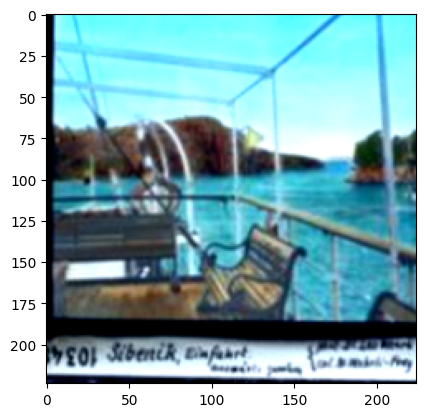

In [ ]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
# print images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(images[0])

In [ ]:
import torch

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Load pre-trained convnect model
model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False


num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, 51)  # 51 classes in GLDv2 Top 51 Categories
model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 169MB/s]


In [ ]:
learning_rate = 1e-3
epochs_head = 7

print_every = 50

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.classifier.parameters(), lr=learning_rate, weight_decay=0.0001, betas=(0.9, 0.999))

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
train_losses, val_losses, val_acc = [], [], []
steps = 0

for epoch in range(epochs_head):
    model.train()
    running_loss = 0.0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs_head}"):
        steps += 1

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    # ---- Validation (CORRECTED ACCURACY) ----
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to(device)
            val_labels = val_labels.to(device)

            val_outputs = model(val_inputs)
            loss = criterion(val_outputs, val_labels)
            val_loss += loss.item()

            preds = val_outputs.argmax(dim=1)
            correct += (preds == val_labels).sum().item()
            total += val_labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = correct / total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs_head}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )


Epoch 1/7: 100%|██████████| 456/456 [06:24<00:00,  1.18it/s]


Epoch [1/7] | Train Loss: 1.5131 | Val Loss: 0.8298 | Val Acc: 0.7813


Epoch 2/7: 100%|██████████| 456/456 [06:12<00:00,  1.22it/s]


Epoch [2/7] | Train Loss: 0.7783 | Val Loss: 0.6270 | Val Acc: 0.8324


Epoch 3/7: 100%|██████████| 456/456 [06:19<00:00,  1.20it/s]


...

Epoch [5/7] | Train Loss: 0.4927 | Val Loss: 0.4450 | Val Acc: 0.8740


Epoch 6/7: 100%|██████████| 456/456 [06:18<00:00,  1.20it/s]


Epoch [6/7] | Train Loss: 0.4547 | Val Loss: 0.4186 | Val Acc: 0.8851


Epoch 7/7: 100%|██████████| 456/456 [06:17<00:00,  1.21it/s]


Epoch [7/7] | Train Loss: 0.4239 | Val Loss: 0.4013 | Val Acc: 0.8870


In [ ]:
import os

CHECKPOINT_DIR = "/content/drive/MyDrive/landmark_classification/New_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [ ]:
checkpoint = {
    "epoch": epoch,   # exactly the epoch you finished
    "steps_done": steps,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_acc": val_acc,
}

checkpoint_path = os.path.join(
    CHECKPOINT_DIR, f"checkpoint_epoch_{epoch + 1}.pth"
)

torch.save(checkpoint, checkpoint_path)
print(f"✅ Checkpoint saved at: {checkpoint_path}")

✅ Checkpoint saved at: /content/drive/MyDrive/landmark_classification/New_checkpoints/checkpoint_epoch_7.pth


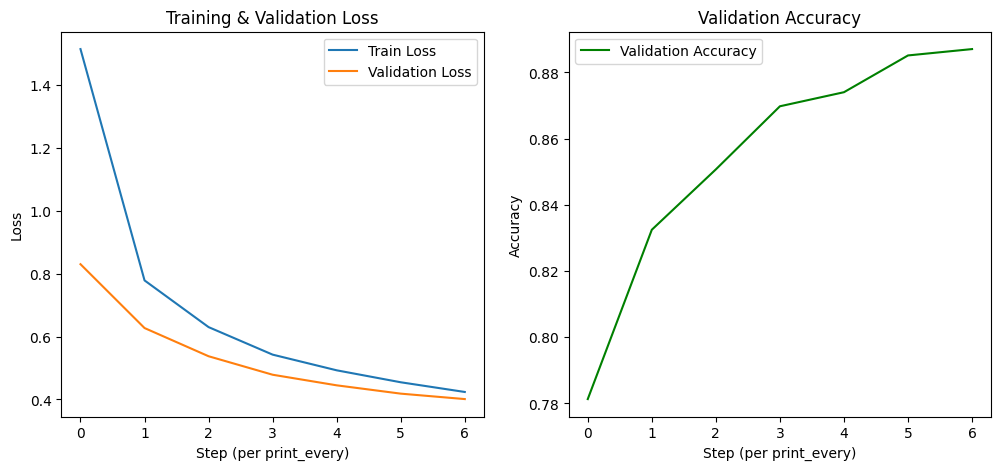

In [ ]:
train_losses = train_losses
val_losses = val_losses
val_accuracies = val_acc
# -----------------------------
# Plot metrics
# -----------------------------
os.makedirs('output', exist_ok=True)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Step (per print_every)")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Validation Accuracy", color='green')
plt.xlabel("Step (per print_every)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.savefig('output/training_validation_head_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze backbone (ConvNeXt features)
for param in model.features[-2].parameters():
    param.requires_grad = True

# Head is already trainable, usually
for param in model.classifier.parameters():
    param.requires_grad = True



In [ ]:
import torch.optim as optim
import torch.nn as nn

epochs_finetune = 3
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW([
    {'params': model.features[-2].parameters(), 'lr': 1e-4, 'weight_decay': 0.01},
    {'params': model.classifier.parameters(), 'lr': 1e-3, 'weight_decay': 0.01}
], betas=(0.9, 0.999))  # default betas for AdamW

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_finetune)

In [ ]:
print("Starting finetuning of last 2 layers...")
train_losses_ft, val_losses_ft, val_acc_ft = [], [], []
steps = 0
for epoch in range(epochs_finetune):
    running_loss = 0
    model.train()
    for inputs, labels in train_loader:
        steps += 1
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        # Validation
        if steps % print_every == 0:
            model.eval()
            val_loss = 0
            accuracy = 0
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_outputs = model(val_inputs)
                    batch_loss = criterion(val_outputs, val_labels)
                    val_loss += batch_loss.item()

                    preds = val_outputs.argmax(dim=1)
                    accuracy += torch.sum(preds == val_labels).item() / len(val_labels)

            train_losses_ft.append(running_loss / print_every)
            val_losses_ft.append(val_loss / len(val_loader))
            val_acc_ft.append(accuracy / len(val_loader))

            print(f"Epoch {epoch+1}/{epochs_finetune} | Step {steps} | "
                  f"Train Loss: {running_loss/print_every:.3f} | "
                  f"Val Loss: {val_loss/len(val_loader):.3f} | "
                  f"Val Acc: {accuracy/len(val_loader):.3f}")

            running_loss = 0
            model.train()

Starting finetuning of last 2 layers...
Epoch 1/3 | Step 50 | Train Loss: 0.068 | Val Loss: 0.147 | Val Acc: 0.955
Epoch 1/3 | Step 100 | Train Loss: 0.059 | Val Loss: 0.148 | Val Acc: 0.954
Epoch 1/3 | Step 150 | Train Loss: 0.066 | Val Loss: 0.146 | Val Acc: 0.955
Epoch 1/3 | Step 200 | Train Loss: 0.071 | Val Loss: 0.146 | Val Acc: 0.956
Epoch 1/3 | Step 250 | Train Loss: 0.078 | Val Loss: 0.147 | Val Acc: 0.954
Epoch 1/3 | Step 300 | Train Loss: 0.070 | Val Loss: 0.145 | Val Acc: 0.956
Epoch 1/3 | Step 350 | Train Loss: 0.071 | Val Loss: 0.147 | Val Acc: 0.955
Epoch 1/3 | Step 400 | Train Loss: 0.060 | Val Loss: 0.140 | Val Acc: 0.955
Epoch 1/3 | Step 450 | Train Loss: 0.071 | Val Loss: 0.144 | Val Acc: 0.954
Epoch 2/3 | Step 500 | Train Loss: 0.058 | Val Loss: 0.146 | Val Acc: 0.956
Epoch 2/3 | Step 550 | Train Loss: 0.058 | Val Loss: 0.147 | Val Acc: 0.954
Epoch 2/3 | Step 600 | Train Loss: 0.060 | Val Loss: 0.148 | Val Acc: 0.955
Epoch 2/3 | Step 650 | Train Loss: 0.057 | Val Lo

In [ ]:

CHECKPOINT_DIR = "/content/drive/MyDrive/landmark_classification/new_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint = {
    "epoch": epoch,   # exactly the epoch you finished
    "steps_done": steps,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "train_losses": train_losses_ft,
    "val_losses": val_losses_ft,
    "val_acc": val_acc_ft,
}

checkpoint_path = os.path.join(
    CHECKPOINT_DIR, f"checkpoint_finetune_epoch_{epoch + 1}.pth"
)

torch.save(checkpoint, checkpoint_path)
print(f"✅ Checkpoint saved at: {checkpoint_path}")

✅ Checkpoint saved at: /content/drive/MyDrive/landmark_classification/new_checkpoints/checkpoint_finetune_epoch_3.pth


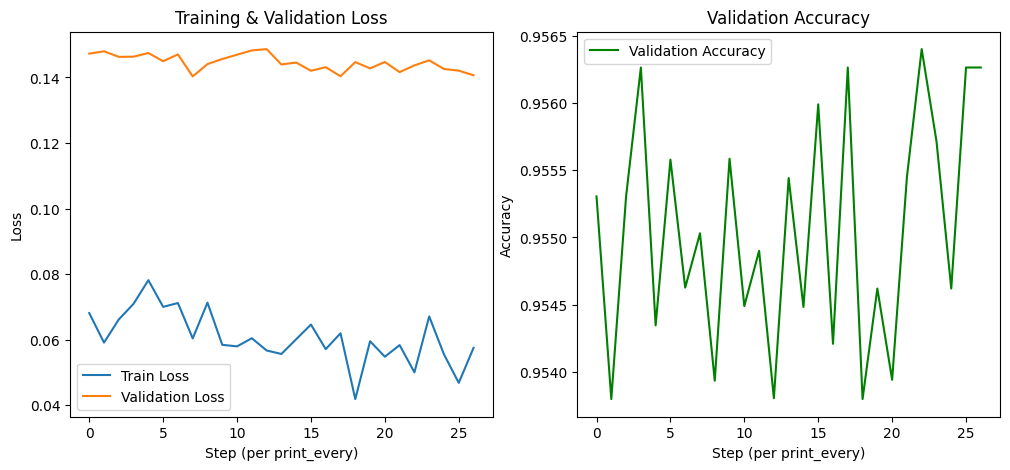

In [ ]:
train_losses = train_losses_ft
val_losses = val_losses_ft
val_accuracies = val_acc_ft
# -----------------------------
# Plot metrics
# -----------------------------
os.makedirs('output', exist_ok=True)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Step (per print_every)")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Validation Accuracy", color='green')
plt.xlabel("Step (per print_every)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.savefig('output/training_validation_head_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1)

# Adjust the classifier for 51 classes
num_ftrs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_ftrs, 51)

# Move to device
model = model.to(device)


In [ ]:
optimizer = torch.optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=0.0001)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
# Load the checkpoint
checkpoint_path = "/content/drive/MyDrive/landmark_classification/new_checkpoints/checkpoint_finetune_epoch_3.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Load model weights
model.load_state_dict(checkpoint["model_state"])

# Optional: load optimizer and scheduler if you want to continue training exactly
optimizer.load_state_dict(checkpoint["optimizer_state"])
scheduler.load_state_dict(checkpoint["scheduler_state"])

# Optional: resume epoch count
start_epoch = checkpoint["epoch"] + 1

# Optional: training history
train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]
val_acc = checkpoint["val_acc"]
total_epoch = 6

In [ ]:

# 3️⃣ Freeze all layers first (optional, safety step)
for param in model.parameters():
    param.requires_grad = False

# 4️⃣ Gradually unfreeze layers
# Example: unfreeze last 5 layers of features + classifier
for param in model.features[-5:].parameters():  # adjust index as needed
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4}
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

criterion = nn.CrossEntropyLoss()


In [ ]:

steps = 0
for epoch in range(start_epoch, total_epoch):
    running_loss = 0
    model.train()
    for inputs, labels in train_loader:
        steps += 1
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        # Validation
        if steps % print_every == 0:
            model.eval()
            val_loss = 0
            accuracy = 0
            with torch.no_grad():
                for val_inputs, val_labels in val_loader:
                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_outputs = model(val_inputs)
                    batch_loss = criterion(val_outputs, val_labels)
                    val_loss += batch_loss.item()

                    preds = val_outputs.argmax(dim=1)
                    accuracy += torch.sum(preds == val_labels).item() / len(val_labels)

            train_losses_ft.append(running_loss / print_every)
            val_losses_ft.append(val_loss / len(val_loader))
            val_acc_ft.append(accuracy / len(val_loader))

            print(f"Epoch {epoch+1}/{epochs_finetune} | Step {steps} | "
                  f"Train Loss: {running_loss/print_every:.3f} | "
                  f"Val Loss: {val_loss/len(val_loader):.3f} | "
                  f"Val Acc: {accuracy/len(val_loader):.3f}")

            running_loss = 0
            model.train()

Epoch 4/3 | Step 50 | Train Loss: 2.532 | Val Loss: 1.501 | Val Acc: 0.642
Epoch 4/3 | Step 100 | Train Loss: 1.233 | Val Loss: 0.865 | Val Acc: 0.770
Epoch 4/3 | Step 150 | Train Loss: 0.824 | Val Loss: 0.636 | Val Acc: 0.826
Epoch 4/3 | Step 200 | Train Loss: 0.652 | Val Loss: 0.505 | Val Acc: 0.862
Epoch 4/3 | Step 250 | Train Loss: 0.552 | Val Loss: 0.442 | Val Acc: 0.876
Epoch 4/3 | Step 300 | Train Loss: 0.474 | Val Loss: 0.375 | Val Acc: 0.894
Epoch 4/3 | Step 350 | Train Loss: 0.431 | Val Loss: 0.349 | Val Acc: 0.898
Epoch 4/3 | Step 400 | Train Loss: 0.368 | Val Loss: 0.311 | Val Acc: 0.911
Epoch 4/3 | Step 450 | Train Loss: 0.367 | Val Loss: 0.281 | Val Acc: 0.918
Epoch 5/3 | Step 500 | Train Loss: 0.221 | Val Loss: 0.260 | Val Acc: 0.923
Epoch 5/3 | Step 550 | Train Loss: 0.244 | Val Loss: 0.260 | Val Acc: 0.922
Epoch 5/3 | Step 600 | Train Loss: 0.253 | Val Loss: 0.233 | Val Acc: 0.933
Epoch 5/3 | Step 650 | Train Loss: 0.233 | Val Loss: 0.211 | Val Acc: 0.936
Epoch 5/3 | S

In [ ]:
CHECKPOINT_DIR = "/content/drive/MyDrive/landmark_classification/new_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint = {
    "epoch": epoch,   # exactly the epoch you finished
    "steps_done": steps,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "train_losses": train_losses_ft,
    "val_losses": val_losses_ft,
    "val_acc": val_acc_ft,
}

checkpoint_path = os.path.join(
    CHECKPOINT_DIR, f"checkpoint_finetune_epoch_{epoch + 1}.pth"
)

torch.save(checkpoint, checkpoint_path)
print(f"✅ Checkpoint saved at: {checkpoint_path}")

✅ Checkpoint saved at: /content/drive/MyDrive/landmark_classification/new_checkpoints/checkpoint_finetune_epoch_6.pth


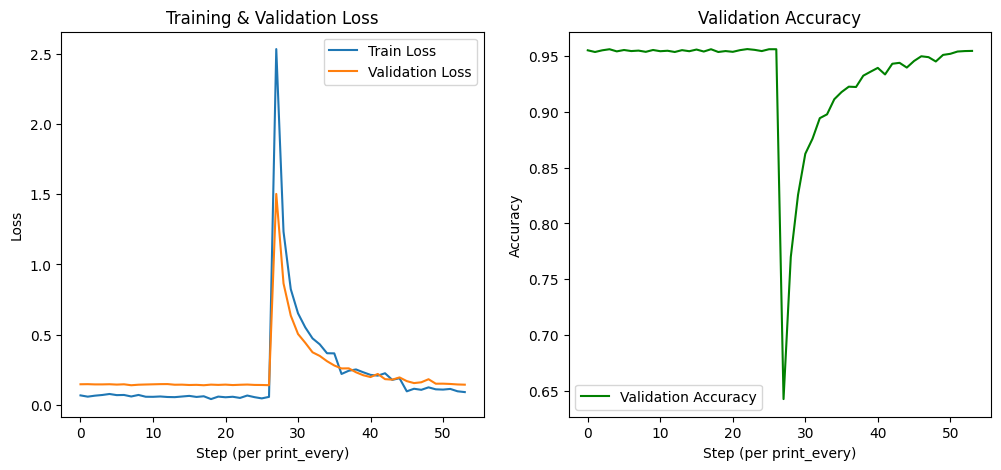

In [ ]:
train_losses = train_losses_ft
val_losses = val_losses_ft
val_accuracies = val_acc_ft
# -----------------------------
# Plot metrics
# -----------------------------
os.makedirs('output', exist_ok=True)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Step (per print_every)")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label="Validation Accuracy", color='green')
plt.xlabel("Step (per print_every)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.savefig('output/training_validation_head_metrics.png', dpi=300, bbox_inches='tight')
plt.show()